In [1]:
import xarray as xr
import matplotlib.pyplot as mp 

Text(0.5, 1.0, 'CAM7 - Flipped Sign')

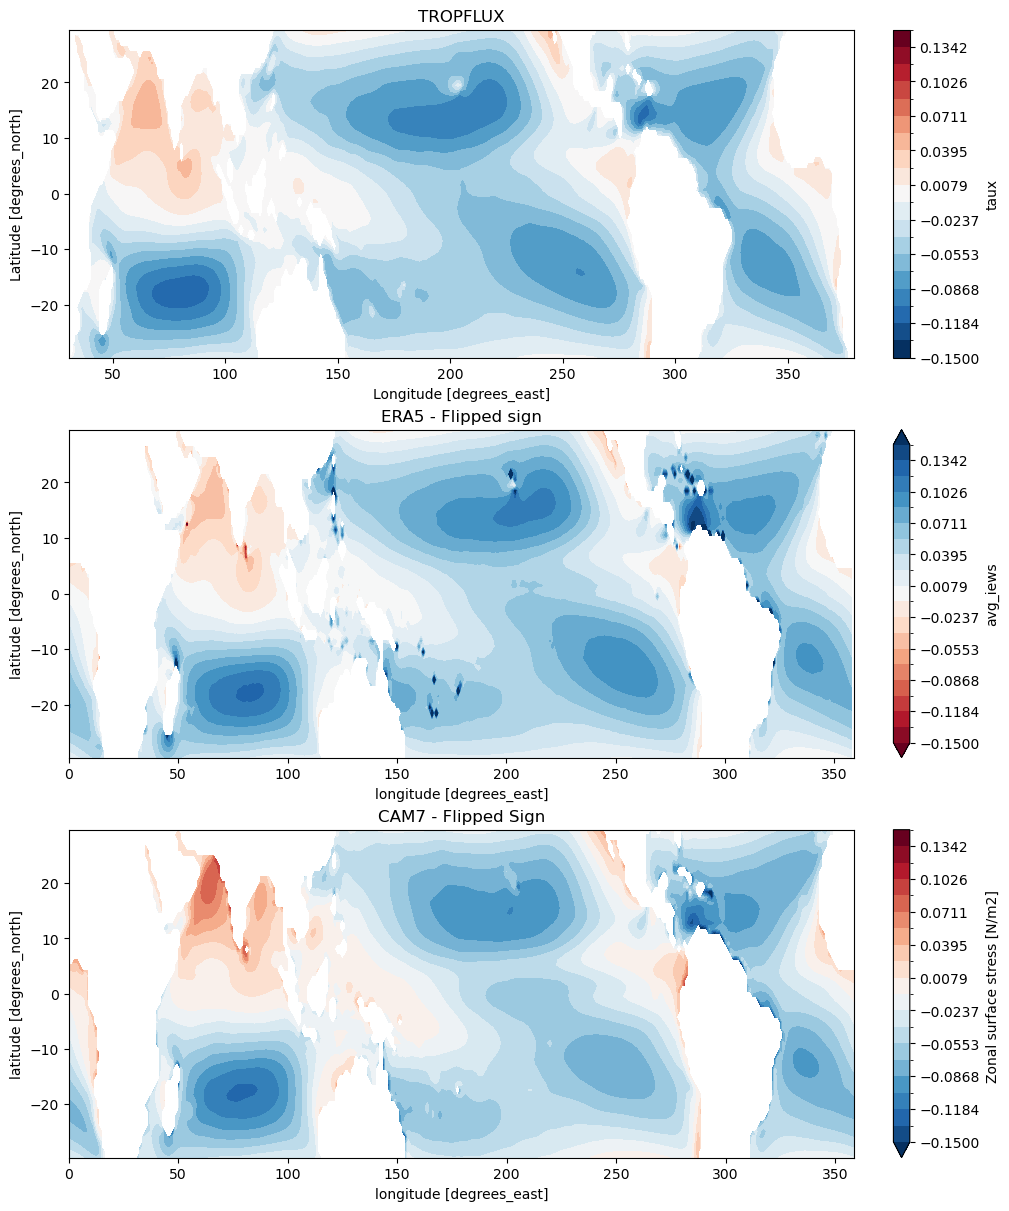

In [51]:
tfile = '/glade/work/rneale/data/tropflux/taux_tropflux_1m_1979-2018.nc'
#efile = '/glade/derecho/scratch/rneale/ERA5/mmean/1deg/taux_era5_monthly_1x1.nc'

efile = '/glade/derecho/scratch/rneale/ERA5/mmean/1deg/taux2_era5_monthly_1x1.nc'

cfile = '/glade/derecho/scratch/rneale/archive/f.cam6_4_032.FLTHIST_ne30.cam7_ke.001a/climo/f.cam6_4_032.FLTHIST_ne30.cam7_ke.001a_ANN_climo.nc'


ds_t = xr.open_dataset(tfile)
ds_e = xr.open_dataset(efile)
ds_c = xr.open_dataset(cfile)

da_t = ds_t['taux'].sel(latitude=slice(-30, 30)).mean(dim='time')
da_e = -ds_e['avg_iews'].sel(lat=slice(-30, 30)).mean(dim='valid_time')
da_c = -ds_c['TAUX'].sel(lat=slice(-30, 30)).squeeze()

lfrac_c = ds_c['LANDFRAC'].sel(lat=slice(-30, 30)).squeeze()

#display(da_t)
#display(da_e)

#da_t.plot.contourf()
#da_e.plot.contourf()

lfrac_e = lfrac_c.interp_like(da_e)
da_c = da_c.where(lfrac_c < 0.5)
da_e = da_e.where(lfrac_e < 0.5)


vmin = -0.15
vmax = 0.15

# Create side-by-side plots
fig, axes = mp.subplots(3, 1, figsize=(10, 12), constrained_layout=True)

# Plot with consistent color range
da_t.plot.contourf(ax=axes[0], vmin=vmin, vmax=vmax, levels =20, cmap='RdBu_r')
axes[0].set_title('TROPFLUX')

da_e.plot.contourf(ax=axes[1], vmin=vmin, vmax=vmax, levels=20, cmap='RdBu')
axes[1].set_title('ERA5 - Flipped sign')

da_c.plot.contourf(ax=axes[2], vmin=vmin, vmax=vmax, levels =20, cmap='RdBu_r')
axes[2].set_title('CAM7 - Flipped Sign')

